In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset and immediately parse the date column
# parse_dates tells pandas to convert that column from string to datetime
df = pd.read_csv("../data/Sample - Superstore.csv",
                 parse_dates=["Order Date", "Ship Date"],
                 encoding="latin-1")

# Basic shape check — how many rows and columns do we have
print("Shape:", df.shape)

# Column names and data types — confirm Order Date is datetime, not object
print("\nData types:\n", df.dtypes)

# Quick look at the first few rows
df.head()

Shape: (9994, 21)

Data types:
 Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code               int64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
# Question 1 — what time period does the data cover
print("Date range:")
print("Start:", df["Order Date"].min())
print("End:  ", df["Order Date"].max())

# Question 2 and 3 — missing values across all columns
print("\nMissing values:")
print(df.isnull().sum())

# Question 4 — unique business dimensions
print("\nRegions:   ", df["Region"].unique())
print("Segments:  ", df["Segment"].unique())
print("Categories:", df["Category"].unique())

# Distribution of sales and profit — are there negative profits
print("\nSales and Profit summary:")
print(df[["Sales", "Profit"]].describe())

Date range:
Start: 2014-01-03 00:00:00
End:   2017-12-30 00:00:00

Missing values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Regions:    <StringArray>
['South', 'West', 'Central', 'East']
Length: 4, dtype: str
Segments:   <StringArray>
['Consumer', 'Corporate', 'Home Office']
Length: 3, dtype: str
Categories: <StringArray>
['Furniture', 'Office Supplies', 'Technology']
Length: 3, dtype: str

Sales and Profit summary:
              Sales       Profit
count   9994.000000  9994.000000
mean     229.858001    28.656896
std      623.245101   234.260108
min        0.444000 -6599.978000
25%       17.280000     1.728750
50%       

In [4]:
# Extract year and month as separate columns for grouping later
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month

# Create a year-month period column for continuous monthly trend plotting
# Period("M") means we are grouping at monthly frequency
df["YearMonth"] = df["Order Date"].dt.to_period("M")

# Confirm the new columns look correct
print(df[["Order Date", "Year", "Month", "YearMonth"]].head(10))

  Order Date  Year  Month YearMonth
0 2016-11-08  2016     11   2016-11
1 2016-11-08  2016     11   2016-11
2 2016-06-12  2016      6   2016-06
3 2015-10-11  2015     10   2015-10
4 2015-10-11  2015     10   2015-10
5 2014-06-09  2014      6   2014-06
6 2014-06-09  2014      6   2014-06
7 2014-06-09  2014      6   2014-06
8 2014-06-09  2014      6   2014-06
9 2014-06-09  2014      6   2014-06


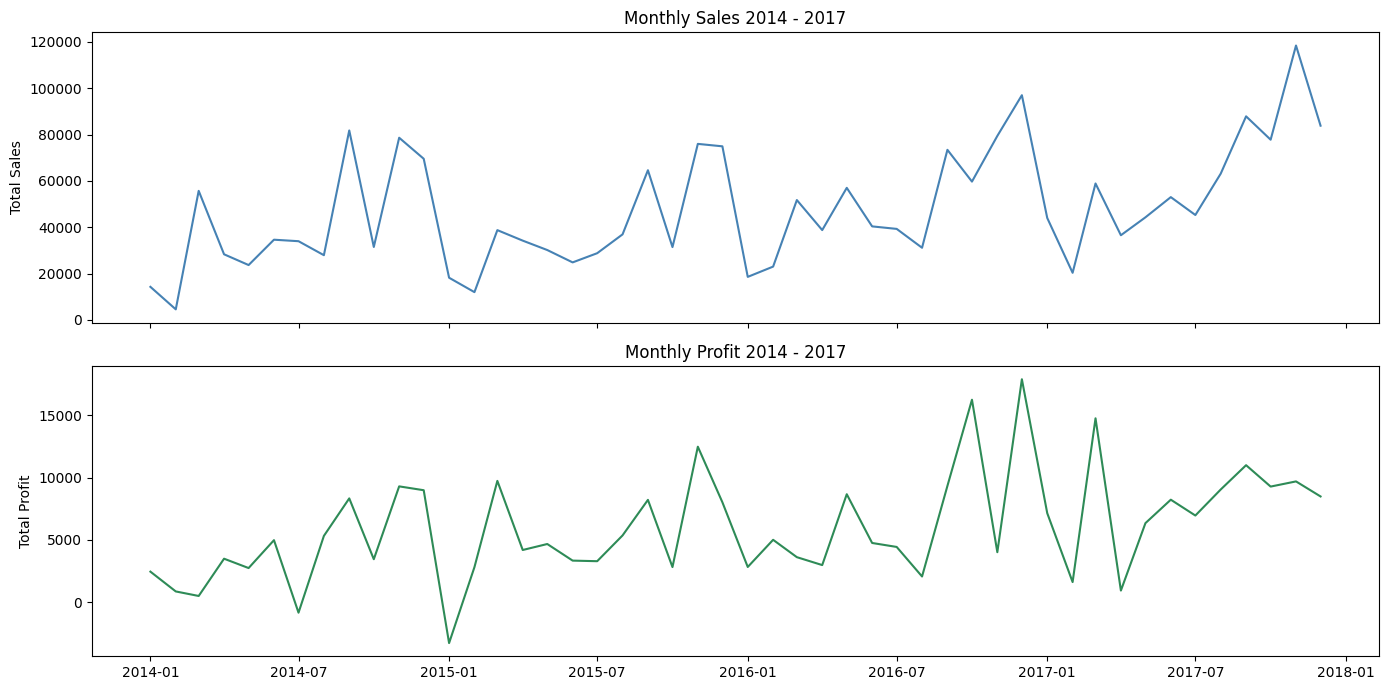

In [6]:
# Group all orders by YearMonth and sum sales and profit for each month
# This collapses 9994 rows into one row per month
monthly = df.groupby("YearMonth")[["Sales", "Profit"]].sum()

# Convert the Period index to timestamp so matplotlib can plot it cleanly
monthly.index = monthly.index.to_timestamp()

# Plot both sales and profit on the same figure
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Sales trend
axes[0].plot(monthly.index, monthly["Sales"], color="steelblue", linewidth=1.5)
axes[0].set_title("Monthly Sales 2014 - 2017")
axes[0].set_ylabel("Total Sales")

# Profit trend
axes[1].plot(monthly.index, monthly["Profit"], color="seagreen", linewidth=1.5)
axes[1].set_title("Monthly Profit 2014 - 2017")
axes[1].set_ylabel("Total Profit")

plt.tight_layout()
plt.show()

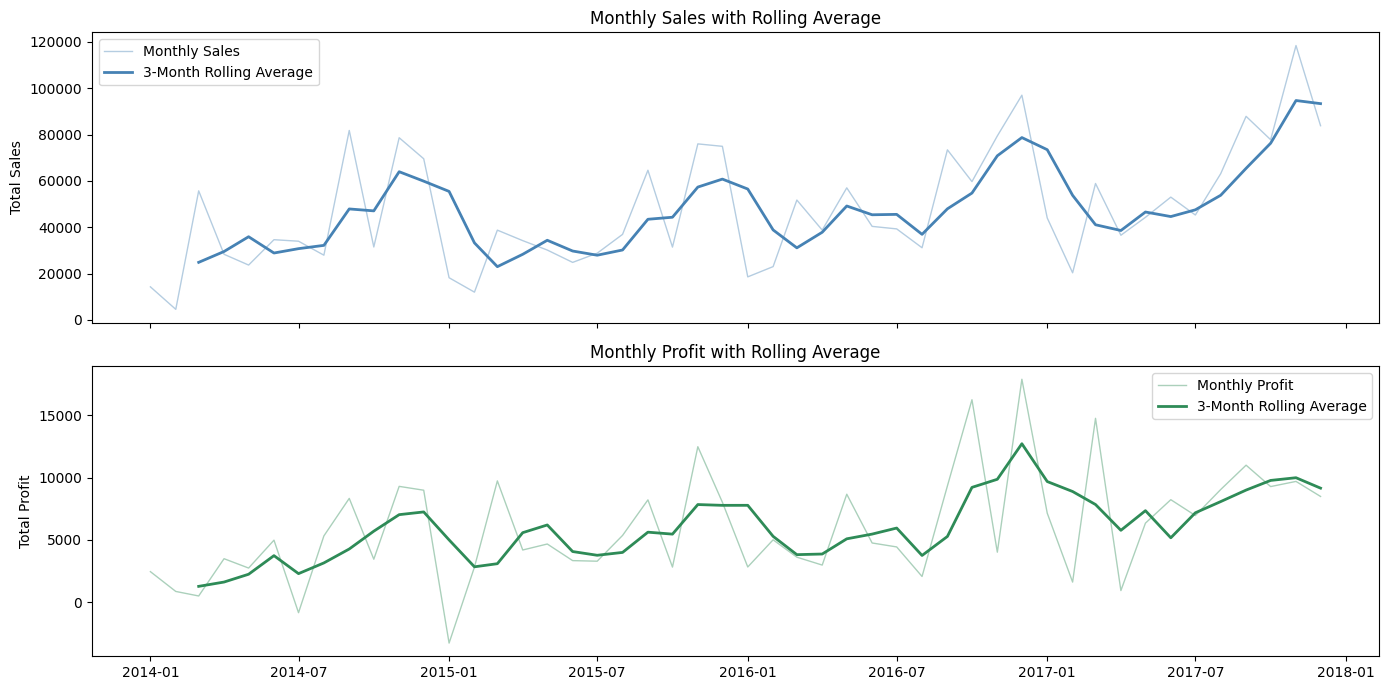

In [7]:
# A rolling average of window=3 means each point is the average
# of that month and the 2 months before it
# This smooths short term noise while preserving the real trend
monthly["Sales_Rolling"] = monthly["Sales"].rolling(window=3).mean()
monthly["Profit_Rolling"] = monthly["Profit"].rolling(window=3).mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Sales — raw line vs smoothed rolling average
axes[0].plot(monthly.index, monthly["Sales"], color="steelblue",
             linewidth=1, alpha=0.4, label="Monthly Sales")
axes[0].plot(monthly.index, monthly["Sales_Rolling"], color="steelblue",
             linewidth=2, label="3-Month Rolling Average")
axes[0].set_title("Monthly Sales with Rolling Average")
axes[0].set_ylabel("Total Sales")
axes[0].legend()

# Profit — raw line vs smoothed rolling average
axes[1].plot(monthly.index, monthly["Profit"], color="seagreen",
             linewidth=1, alpha=0.4, label="Monthly Profit")
axes[1].plot(monthly.index, monthly["Profit_Rolling"], color="seagreen",
             linewidth=2, label="3-Month Rolling Average")
axes[1].set_title("Monthly Profit with Rolling Average")
axes[1].set_ylabel("Total Profit")
axes[1].legend()

plt.tight_layout()
plt.show()

In [8]:
# Calculate profit margin per category
# Profit margin = (total profit / total sales) * 100
category_metrics = df.groupby("Category")[["Sales", "Profit"]].sum()
category_metrics["Profit_Margin"] = (
    category_metrics["Profit"] / category_metrics["Sales"] * 100
).round(2)

print("Category Performance:")
print(category_metrics)

# Calculate regional performance
region_metrics = df.groupby("Region")[["Sales", "Profit"]].sum()
region_metrics["Profit_Margin"] = (
    region_metrics["Profit"] / region_metrics["Sales"] * 100
).round(2)

print("\nRegional Performance:")
print(region_metrics)

Category Performance:
                       Sales       Profit  Profit_Margin
Category                                                
Furniture        741999.7953   18451.2728           2.49
Office Supplies  719047.0320  122490.8008          17.04
Technology       836154.0330  145454.9481          17.40

Regional Performance:
               Sales       Profit  Profit_Margin
Region                                          
Central  501239.8908   39706.3625           7.92
East     678781.2400   91522.7800          13.48
South    391721.9050   46749.4303          11.93
West     725457.8245  108418.4489          14.94


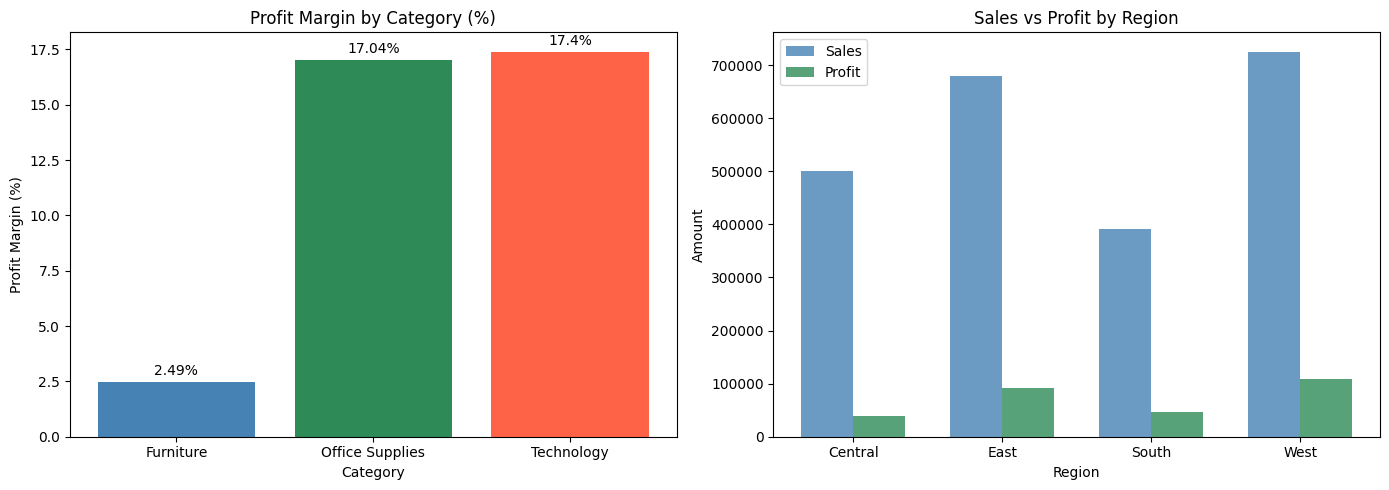

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Category profit margin bar chart
axes[0].bar(category_metrics.index,
            category_metrics["Profit_Margin"],
            color=["steelblue", "seagreen", "tomato"])
axes[0].set_title("Profit Margin by Category (%)")
axes[0].set_ylabel("Profit Margin (%)")
axes[0].set_xlabel("Category")

# Add the actual margin value on top of each bar for readability
for i, val in enumerate(category_metrics["Profit_Margin"]):
    axes[0].text(i, val + 0.3, f"{val}%", ha="center", fontsize=10)

# Regional performance — grouped bar for sales and profit
x = range(len(region_metrics.index))
width = 0.35

axes[1].bar([i - width/2 for i in x], region_metrics["Sales"],
            width=width, label="Sales", color="steelblue", alpha=0.8)
axes[1].bar([i + width/2 for i in x], region_metrics["Profit"],
            width=width, label="Profit", color="seagreen", alpha=0.8)
axes[1].set_title("Sales vs Profit by Region")
axes[1].set_ylabel("Amount")
axes[1].set_xlabel("Region")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(region_metrics.index)
axes[1].legend()

plt.tight_layout()
plt.show()

In [10]:
# Define what counts as a low profit margin for this business
LOW_MARGIN_THRESHOLD = 5.0

insights = []  # We will collect all generated insights here as strings

# Rule 1 — flag any category with profit margin below threshold
for category, row in category_metrics.iterrows():
    if row["Profit_Margin"] < LOW_MARGIN_THRESHOLD:
        insights.append(
            f"WARNING: {category} has a low profit margin of "
            f"{row['Profit_Margin']}% — investigate discounting or costs."
        )

# Rule 2 — find the weakest region by profit margin and flag it
weakest_region = region_metrics["Profit_Margin"].idxmin()
weakest_margin = region_metrics.loc[weakest_region, "Profit_Margin"].round(2)
insights.append(
    f"ALERT: {weakest_region} is the weakest performing region "
    f"with a profit margin of {weakest_margin}%."
)

# Rule 3 — find the strongest region and highlight it
strongest_region = region_metrics["Profit_Margin"].idxmax()
strongest_margin = region_metrics.loc[strongest_region, "Profit_Margin"].round(2)
insights.append(
    f"INSIGHT: {strongest_region} is the top performing region "
    f"with a profit margin of {strongest_margin}% — analyse for best practices."
)

# Rule 4 — flag months where profit was negative
negative_profit_months = monthly[monthly["Profit"] < 0]
if len(negative_profit_months) > 0:
    insights.append(
        f"WARNING: {len(negative_profit_months)} month(s) recorded negative "
        f"profit — review transactions in those periods."
    )

# Print all generated insights
print("=== SentinelIQ Automated Insights ===\n")
for insight in insights:
    print("-", insight)

=== SentinelIQ Automated Insights ===

- WARNING: Furniture has a low profit margin of 2.49% — investigate discounting or costs.
- ALERT: Central is the weakest performing region with a profit margin of 7.92%.
- INSIGHT: West is the top performing region with a profit margin of 14.94% — analyse for best practices.
- WARNING: 2 month(s) recorded negative profit — review transactions in those periods.


In [11]:
# Identify which specific months had negative total profit
print("Months with negative profit:\n")
print(negative_profit_months[["Sales", "Profit"]])

# Now find which category was responsible during those periods
# First convert YearMonth back to year and month integers for filtering
negative_months_list = negative_profit_months.index.to_period("M")

# Filter original dataframe to only rows falling in those months
mask = df["YearMonth"].isin(negative_months_list)
problem_rows = df[mask]

# Break down sales and profit by category during those months
print("\nCategory breakdown during negative profit months:")
print(problem_rows.groupby("Category")[["Sales", "Profit"]].sum())

# Check discount levels during those months vs overall average
print("\nAverage discount during negative months:",
      problem_rows["Discount"].mean().round(3))
print("Average discount overall:",
      df["Discount"].mean().round(3))

Months with negative profit:

                 Sales     Profit
YearMonth                        
2014-07-01  33946.3930  -841.4826
2015-01-01  18174.0756 -3281.0070

Category breakdown during negative profit months:
                      Sales     Profit
Category                              
Furniture        22560.9926 -2639.9533
Office Supplies  16929.9880 -1892.1203
Technology       12629.4880   409.5840

Average discount during negative months: 0.173
Average discount overall: 0.156
